# 4.6.3 截面与返回中的长期结构

## 学习目标与先修知识

能定义同向截面与返回，插值同一交点的时间和状态（state），并区分完整返回映射与投影（projection）散点。

先修：4.2 的周期与过零检测，4.6.1—4.6.2 的连续积分与步长核验。

## 具体问题

连续绕行的轨迹（trajectory）很难逐圈比较。像每次心搏经过同一相位（phase）做一次记录那样，能否把持续运动变为一列事件？记录时必须固定方向，否则一次周期会被算成两次。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN, GRAY = '#008bfb', '#ff0051', '#009e73', '#555555'

## 初步实验

In [2]:
times=np.arange(0,20.01,.1)
print("圆轨道每隔 2π 返回同一同向截面，理论间隔：",2*math.pi)

圆轨道每隔 2π 返回同一同向截面，理论间隔： 6.283185307179586


## 模型假设

先以解析圆轨道 (x,y,z)=(cos t,0,sin t) 检查事件算法；再对 Lorenz ρ=28，h=.005/.01、总窗 60、暂态（transient） 10，使用 z=27 的正向穿越。

## 数学解释与推导

**庞加莱截面（Poincaré section）**是与流横截的较低维面；在截面上选定方向，将一次交点送往下一次同向交点，得到首次返回映射（first-return map）。周期轨道在适当截面留下重复的同一点，时间差为周期。无交点或相切时，该局部返回问题可能没有定义。

给离散时刻 tᵢ<tᵢ₊₁、三维状态 vᵢ、vᵢ₊₁，接受 zᵢ<c≤zᵢ₊₁。在线段内求解 zᵢ+α(zᵢ₊₁−zᵢ)=c，得
$$\alpha=\frac{c-z_i}{z_{i+1}-z_i},\quad t_*=t_i+\alpha(t_{i+1}-t_i),\quad v_*=v_i+\alpha(v_{i+1}-v_i).$$
严格下端、含等号上端避免端点重复计数。同一个 α 必须同时用于时间和所有状态；暂态按插值后的 t*≥burn 判断。两端同侧仍可能在中间来回穿越，因此这种采样算法会漏事件；减小步长与检查横截性不可省略。

Lorenz 截面 z=ρ−1 上完整状态仍有 (x,y) 两个坐标。绘制 xₙ 对 xₙ₊₁ 是投影，省略了 y；它未必是单值函数。局部伸展让邻近点分离，有界区域限制整体范围，返回时出现折叠的几何图像；这是解释，不是从投影直接推出严格证明。

## 核心实现

把推导逐步写成函数；不以黑箱轨迹代替方程。

In [3]:
def lorenz_rhs(state, sigma=10., rho=28., beta=8/3):
    x,y,z=state
    return np.array([sigma*(y-x),rho*x-y-x*z,x*y-beta*z])

def rk4_step(rhs, state, h):
    a=rhs(state)
    b=rhs(state+h*a/2)
    c=rhs(state+h*b/2)
    d=rhs(state+h*c)
    return state+h*(a+2*b+2*c+d)/6

def lorenz_path(initial, sigma=10., rho=28., beta=8/3, h=.01, steps=4000):
    state=np.array(initial,dtype=float)
    rows=[state.copy()]
    for _ in range(steps):
        state=rk4_step(lambda v:lorenz_rhs(v,sigma,rho,beta),state,h)
        if not np.all(np.isfinite(state)):
            raise ValueError('数值结果非有限，请减小步长并检查参数。')
        rows.append(state.copy())
    return np.array(rows)

def directed_section(times, states, level, burn=0):
    hits=[]
    for i in range(len(times)-1):
        a,b=states[i],states[i+1]
        if a[2]<level<=b[2]:
            fraction=(level-a[2])/(b[2]-a[2])
            time=times[i]+fraction*(times[i+1]-times[i])
            if time>=burn:
                hits.append([time,*(a+fraction*(b-a))])
    return np.array(hits).reshape(-1,4)

## 对照实验

C:\Users\10149\AppData\Local\Temp\ipykernel_32660\1489250168.py:7: UserWarning: The figure layout has changed to tight
  fig.tight_layout();plt.show()


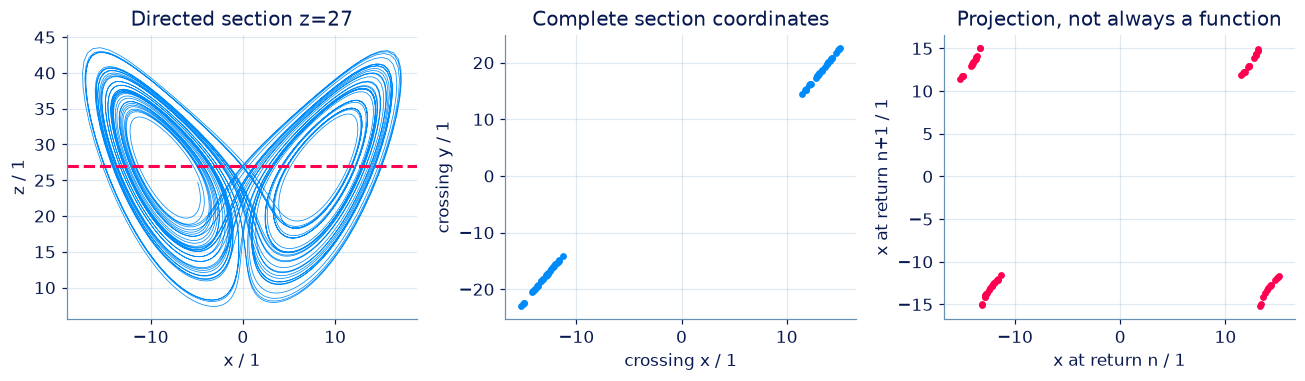

h= 0.04 周期平均误差= 6.10107564469331e-08
h= 0.02 周期平均误差= 6.872563407256393e-08
h= 0.01 周期平均误差= 6.17070838870859e-10
h,暂态,交点数,平均间隔 = 0.01 10 66 0.7561684712099983


h,暂态,交点数,平均间隔 = 0.005 10 67 0.745712607588842


h,暂态,交点数,平均间隔 = 0.005 20 53 0.7473211018157055


In [4]:

times=np.arange(0,60.0001,.01);path=lorenz_path([1,1,1],h=.01,steps=len(times)-1)
hits=directed_section(times,path,27,10)
fig,axes=plt.subplots(1,3,figsize=(12,3.6))
axes[0].plot(path[1000:,0],path[1000:,2],color=BLUE,lw=.5);axes[0].axhline(27,color=PINK,ls='--');axes[0].set(xlabel='x / 1',ylabel='z / 1',title='Directed section z=27')
axes[1].scatter(hits[:,1],hits[:,2],s=12,color=BLUE);axes[1].set(xlabel='crossing x / 1',ylabel='crossing y / 1',title='Complete section coordinates')
axes[2].scatter(hits[:-1,1],hits[1:,1],s=12,color=PINK);axes[2].set(xlabel='x at return n / 1',ylabel='x at return n+1 / 1',title='Projection, not always a function')
fig.tight_layout();plt.show()
for h in [.04,.02,.01]:
    ts=np.arange(0,30+h/2,h);circle=np.column_stack([np.cos(ts),np.zeros(len(ts)),np.sin(ts)])
    roots=directed_section(ts,circle,0,1)
    print('h=',h,'周期平均误差=',abs(np.mean(np.diff(roots[:,0]))-2*math.pi))
for h,burn in [(.01,10),(.005,10),(.005,20)]:
    ps=lorenz_path([1,1,1],h=h,steps=round(60/h));ts=np.arange(len(ps))*h;hs=directed_section(ts,ps,27,burn)
    print('h,暂态,交点数,平均间隔 =',h,burn,len(hs),np.mean(np.diff(hs[:,0])))

## 结果解释

圆轨道的方向规则给出接近 2π 的返回间隔。Lorenz 截面形成分布的交点，投影返回图压缩了状态信息。后两组时域摘要可能不同，不强行要求长窗逐点对齐；先检查短窗事件定位精度，再判断长期结构是否对合理协议变化稳健。

### 独立核对

In [5]:
ts=np.array([0.,1.,2.,3.]);ps=np.array([[0,0,-1],[2,4,1],[4,8,-1],[6,12,1]])
np.testing.assert_allclose(directed_section(ts,ps,0),[[.5,1,2,0],[2.5,5,10,0]])
np.testing.assert_allclose(directed_section(ts,ps,0,1),[[2.5,5,10,0]])
assert directed_section([0,1],np.array([[0,0,1],[0,0,0]]),0).shape==(0,4)
ts=np.arange(0,30.001,.01);circle=np.column_stack([np.cos(ts),np.zeros(len(ts)),np.sin(ts)])
roots=directed_section(ts,circle,0,1)
assert max(abs(np.diff(roots[:,0])-2*math.pi))<1e-6
print('有理插值、暂态边界、无交点与解析周期一致。')

有理插值、暂态边界、无交点与解析周期一致。


[观察轨迹、距离与定向截面](http://127.0.0.1:8000/chapters/04-06-连续时间混沌与奇异吸引子/explore/)：分别改变初值（initial condition）与计算精度，再对照本节推导。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 多项选择题：返回映射保留哪些坐标

在 z=c 的定向截面记录 (xₙ,yₙ)，再画 xₙ 对 xₙ₊₁。哪些说法正确？

- **A.** 完整截面点包含两个坐标。
- **B.** 投影（projection）散点未必是一条单值函数曲线。
- **C.** 同一 x 值必然对应唯一的完整状态（state）。
- **D.** 无交点就能证明没有混沌（chaos）。

[作答：返回映射保留哪些坐标](http://127.0.0.1:8000/chapters/04-06-%E8%BF%9E%E7%BB%AD%E6%97%B6%E9%97%B4%E6%B7%B7%E6%B2%8C%E4%B8%8E%E5%A5%87%E5%BC%82%E5%90%B8%E5%BC%95%E5%AD%90/practice/?question=p04-section-projection)

### 第 2 题 · Python 计算题：提取同向截面交点

给定三维轨迹（trajectory）样本，计算由下向上穿过 z=level 的交点与返回间隔；同一交点的时间和状态（state）必须用相同插值比例。

**函数与代码模板**

```python
def solve(
    times: list[float],
    states: list[list[float]],
    level: float,
    burn: float,
) -> tuple[list[list[float]], list[float]]:
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `times` | `list[float]` | 严格递增的观测（observation）时刻。 | τ |
| `states` | `list[list[float]]` | 与时刻一一对应的三维状态（state）。 | 1 |
| `level` | `float` | 截面高度 c。 | 1 |
| `burn` | `float` | 保留交点的起始时间，含等号。 | τ |

**返回值**

按以下顺序返回元组：(hits, intervals)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `hits` | `list[list[float]]` | 交点列表，每行 [t,x,y,z]；时间单位 τ，其余无量纲（dimensionless）。 | 1 |
| `intervals` | `list[float]` | 相邻保留交点的时间差。 | τ |

**计算规则**

只接受 states[i][2]<level≤states[i+1][2]。用 α=(level−zᵢ)/(zᵢ₊₁−zᵢ) 对时间和三个状态线性插值，仅保留 t≥burn。返回 (hits,intervals)；无交点时均为空列表，只有一个交点时 intervals 为空。端点从下方到达记一次，下一段从等号出发不重复记。

**约束与边界**

- 所有数值有限，不修改输入（input）列表。
- 2≤len(times)=len(states)≤200；每个状态长度 3；时间在 [0,100] 且严格递增；0≤burn≤100；|状态|、|level|≤100。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| times | 严格递增的观测（observation）时刻。 | [0, 1, 2, 3] | τ |
| states | 与时刻一一对应的三维状态（state）。 | [[0, 0, -1], [2, 4, 1], [4, 8, -1], [6, 12, 1]] | 1 |
| level | 截面高度 c。 | 0 | 1 |
| burn | 保留交点的起始时间，含等号。 | 0 | τ |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
times = [0, 1, 2, 3]
states = [[0, 0, -1], [2, 4, 1], [4, 8, -1], [6, 12, 1]]
level = 0
burn = 0

result = solve(times, states, level, burn)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| hits | 交点列表，每行 [t,x,y,z]；时间单位 τ，其余无量纲（dimensionless）。 | [[0.5, 1.0, 2.0, 0.0], [2.5, 5.0, 10.0, 0.0]] | 1 |
| intervals | 相邻保留交点的时间差。 | [2.0] | τ |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([[0.5, 1.0, 2.0, 0.0],
                    [2.5, 5.0, 10.0, 0.0]],
                   [2.0])
```

**样例解释**

第一个交点位于 0 与 1 的中点，故 [t,x,y,z]=[0.5,1,2,0]；下一次为 [2.5,5,10,0]，间隔是 2。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-08。

[作答：提取同向截面交点](http://127.0.0.1:8000/chapters/04-06-%E8%BF%9E%E7%BB%AD%E6%97%B6%E9%97%B4%E6%B7%B7%E6%B2%8C%E4%B8%8E%E5%A5%87%E5%BC%82%E5%90%B8%E5%BC%95%E5%AD%90/practice/?question=p04-directed-section)

### 第 3 题 · Python 计算题：从交点时间估计返回间隔

已得到同向截面的交点时间。计算逐次返回间隔与平均间隔；不足两个交点不虚构周期。

**函数与代码模板**

```python
def solve(
    crossing_times: list[float],
) -> tuple[list[float], float | None]:
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `crossing_times` | `list[float]` | 严格递增的交点时间，可为空。 | τ |

**返回值**

按以下顺序返回元组：(intervals, mean_interval)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `intervals` | `list[float]` | 相邻交点时间差。 | τ |
| `mean_interval` | <code>float &#124; None</code> | 有间隔时的算术平均，否则 None。 | τ |

**计算规则**

返回 (intervals,mean_interval)。间隔数为 max(0,n−1)，无间隔时返回 ([],None)。

**约束与边界**

- 所有数值有限，不修改输入（input）列表。
- 0≤n≤100，时刻有限且严格递增。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| crossing_times | 严格递增的交点时间，可为空。 | [1, 3, 6] | τ |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
crossing_times = [1, 3, 6]

result = solve(crossing_times)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| intervals | 相邻交点时间差。 | [2, 3] | τ |
| mean_interval | 有间隔时的算术平均，否则 None。 | 2.5 | τ |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([2, 3], 2.5)
```

**样例解释**

两次间隔为 2 和 3，均值为 2.5；这只是给定窗口的平均返回时间。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-08。

[作答：从交点时间估计返回间隔](http://127.0.0.1:8000/chapters/04-06-%E8%BF%9E%E7%BB%AD%E6%97%B6%E9%97%B4%E6%B7%B7%E6%B2%8C%E4%B8%8E%E5%A5%87%E5%BC%82%E5%90%B8%E5%BC%95%E5%AD%90/practice/?question=p04-return-intervals)

### 第 4 题 · 单项选择题：没有检测到交点意味着什么

粗采样没有发现 zᵢ<c≤zᵢ₊₁。哪项正确？

- **A.** 可能漏掉段内穿越，应细化采样并检查截面是否横截。
- **B.** 说明完整连续轨迹（trajectory）没有交点。
- **C.** 相切点也总是符合定向穿越规则。
- **D.** 可以把两方向混合以增加样本而不说明。

[作答：没有检测到交点意味着什么](http://127.0.0.1:8000/chapters/04-06-%E8%BF%9E%E7%BB%AD%E6%97%B6%E9%97%B4%E6%B7%B7%E6%B2%8C%E4%B8%8E%E5%A5%87%E5%BC%82%E5%90%B8%E5%BC%95%E5%AD%90/practice/?question=p04-section-limits)

### 参考阅读

[MIT 非线性动力学讲义](https://ocw.mit.edu/courses/12-006j-nonlinear-dynamics-chaos-fall-2022/pages/lecture-notes/)：第 15—16 讲的截面，第 19 讲的奇异几何，第 20—21 讲的 Lorenz 方程，第 24 讲的增长率。核心推导与实验均已写在本节。